# Tutorial 2: FCC-ee linear-optics comparison

This notebook compares the horizontal and vertical beta functions obtained from MAD-X, Xsuite, and an ImpactX envelope calculation. All three codes use the same `fccee_z.madx` lattice and a 45.6 GeV electron reference particle. Run `python fcc_impactx.py` before executing the notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xtrack as xt
from cpymad.madx import Madx

plt.rcParams.update({'font.size': 16, 'figure.figsize': (10, 3)})
LATTICE = Path('fccee_z.madx')
XSUITE_LINE = Path('fccee_p_ring.json')
IMPACTX_DIAGNOSTIC = Path('diags/reduced_beam_characteristics.0.0')
P0C_EV = 45.6e9

## 1. MAD-X reference optics

MAD-X reads the source lattice, selects the `fccee_p_ring` sequence, and computes its periodic Twiss solution. The result serves as the reference because Xsuite imports this same live MAD-X sequence and ImpactX loads the same lattice file.

In [2]:
if not LATTICE.exists():
    raise FileNotFoundError(f'Missing lattice: {LATTICE.resolve()}')

madx = Madx(stdout=False)
madx.input('option, -echo, no_fatal_stop;')
madx.call(str(LATTICE))
madx.beam(particle='electron', pc=P0C_EV / 1e9)
madx.use(sequence='fccee_p_ring')
tw_madx = madx.twiss()

madx_data = {
    's': np.asarray(tw_madx.s),
    'beta_x': np.asarray(tw_madx.betx),
    'beta_y': np.asarray(tw_madx.bety),
}
print(f"MAD-X circumference: {madx_data['s'][-1]:.3f} m")
print(f"MAD-X points: {len(madx_data['s']):,}")

MAD-X circumference: 90644.836 m
MAD-X points: 29,998


## 2. Xsuite optics

Xsuite constructs a thick-element line directly from the MAD-X sequence and saves it as `fccee_p_ring.json`. Later runs load that file instead of repeating the conversion. Assigning the same electron reference momentum keeps the magnetic rigidity consistent. We request a four-dimensional Twiss calculation because this exercise isolates transverse linear optics.

In [3]:
if XSUITE_LINE.exists():
    line = xt.Line.from_json(XSUITE_LINE)
else:
    line = xt.Line.from_madx_sequence(
        madx.sequence.fccee_p_ring,
        allow_thick=True,
        deferred_expressions=True,
    )
    line.particle_ref = xt.Particles(
        mass0=xt.ELECTRON_MASS_EV,
        q0=-1,
        p0c=P0C_EV,
    )
    line.to_json(XSUITE_LINE)
line.build_tracker()
tw_xsuite = line.twiss(method='4d')

xsuite_data = {
    's': np.asarray(tw_xsuite.s),
    'beta_x': np.asarray(tw_xsuite.betx),
    'beta_y': np.asarray(tw_xsuite.bety),
}
print(f"Xsuite line length: {line.get_length():.3f} m")
print(f"Xsuite points: {len(xsuite_data['s']):,}")

Loading line from dict:   0%|          | 0/29998 [00:00<?, ?it/s]

Done loading line from dict.           
Xsuite line length: 90644.836 m
Xsuite points: 29,999


## 3. ImpactX envelope result

For a linear transport map $R(s)$, ImpactX advances the beam covariance as

$$\Sigma(s)=R(s)\Sigma(0)R(s)^{\mathsf T}.$$

The beta function is recovered from $\beta_u=\Sigma_{uu}/\varepsilon_u$. Envelope tracking avoids macroparticle sampling noise, so differences here mainly probe lattice translation, element slicing, and coordinate conventions.

In [4]:
if not IMPACTX_DIAGNOSTIC.exists():
    raise FileNotFoundError(
        f'Missing {IMPACTX_DIAGNOSTIC}. Run: python fcc_impactx.py'
    )
impactx = pd.read_csv(IMPACTX_DIAGNOSTIC, sep=r'\s+')
print(f'ImpactX diagnostic: {IMPACTX_DIAGNOSTIC}')
print(f'ImpactX diagnostic rows: {len(impactx):,}')

ImpactX diagnostic: diags/reduced_beam_characteristics.0.0
ImpactX diagnostic rows: 44,089


## 4. Compare the beta functions

The full-ring logarithmic view checks the global optics and extreme low-beta/high-beta regions. The first 2 km view makes local differences easier to see. Curves need not share identical longitudinal sampling because each code records at its own element or slice boundaries.

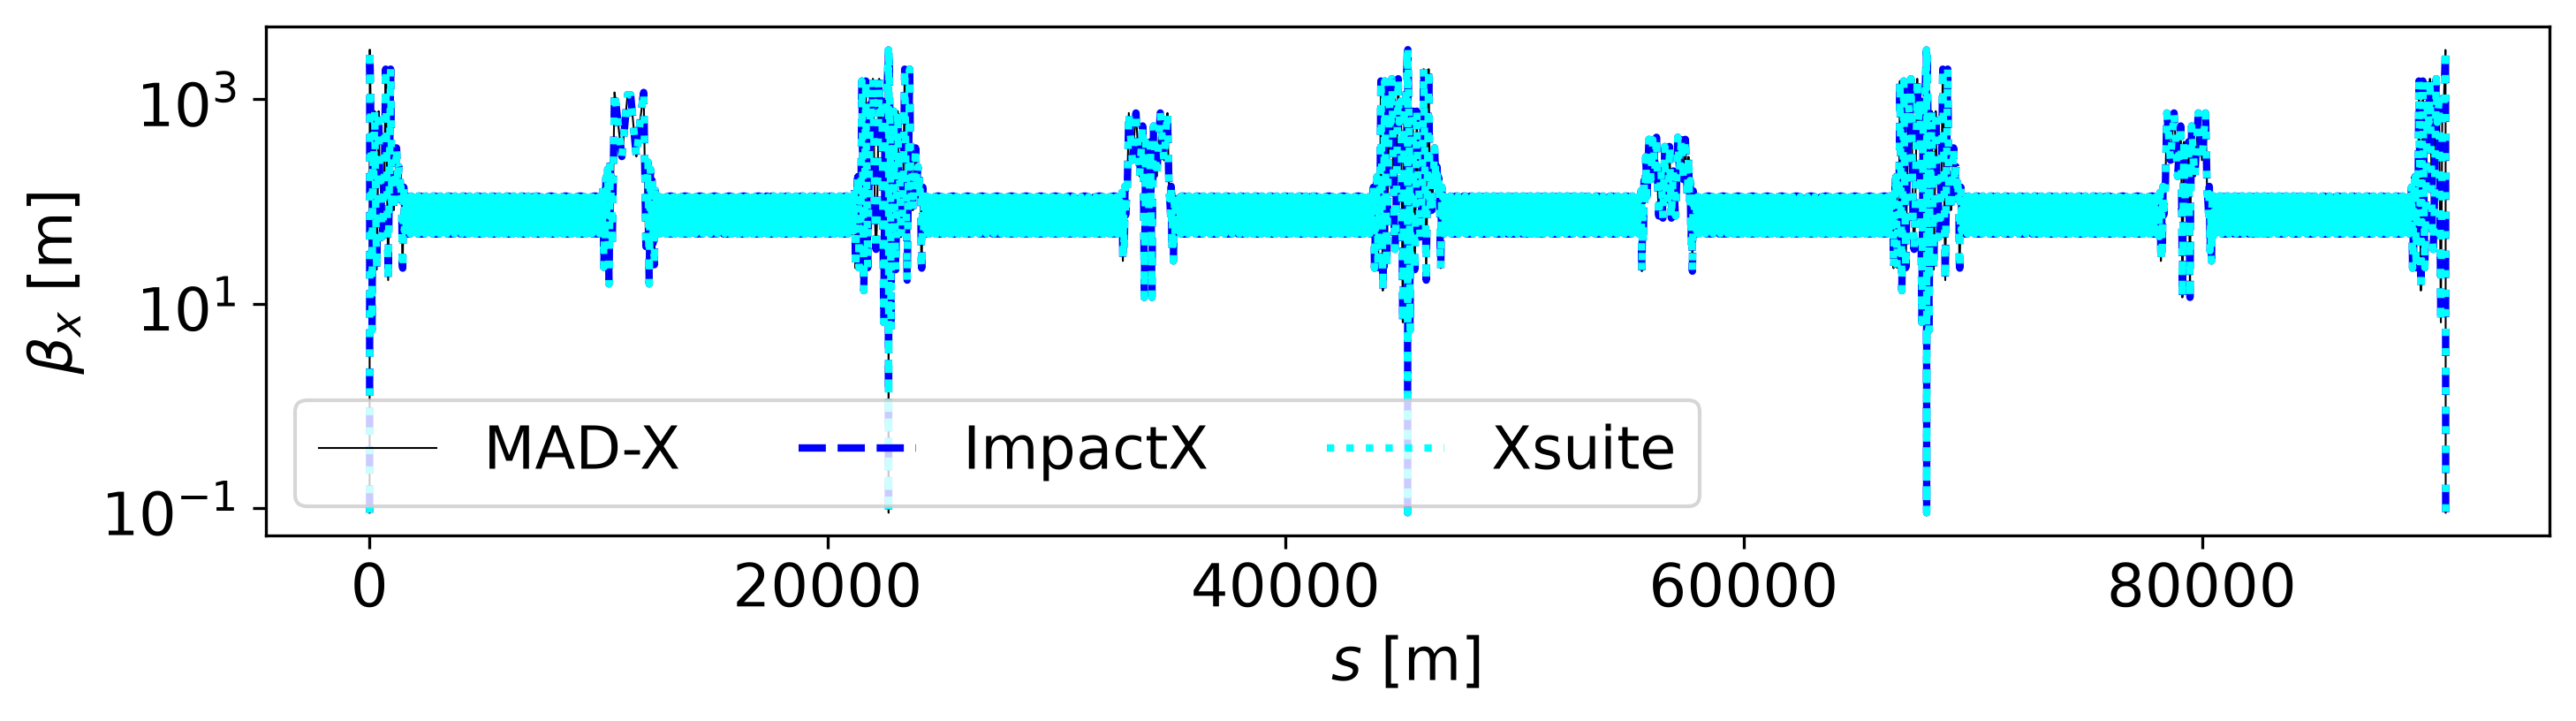

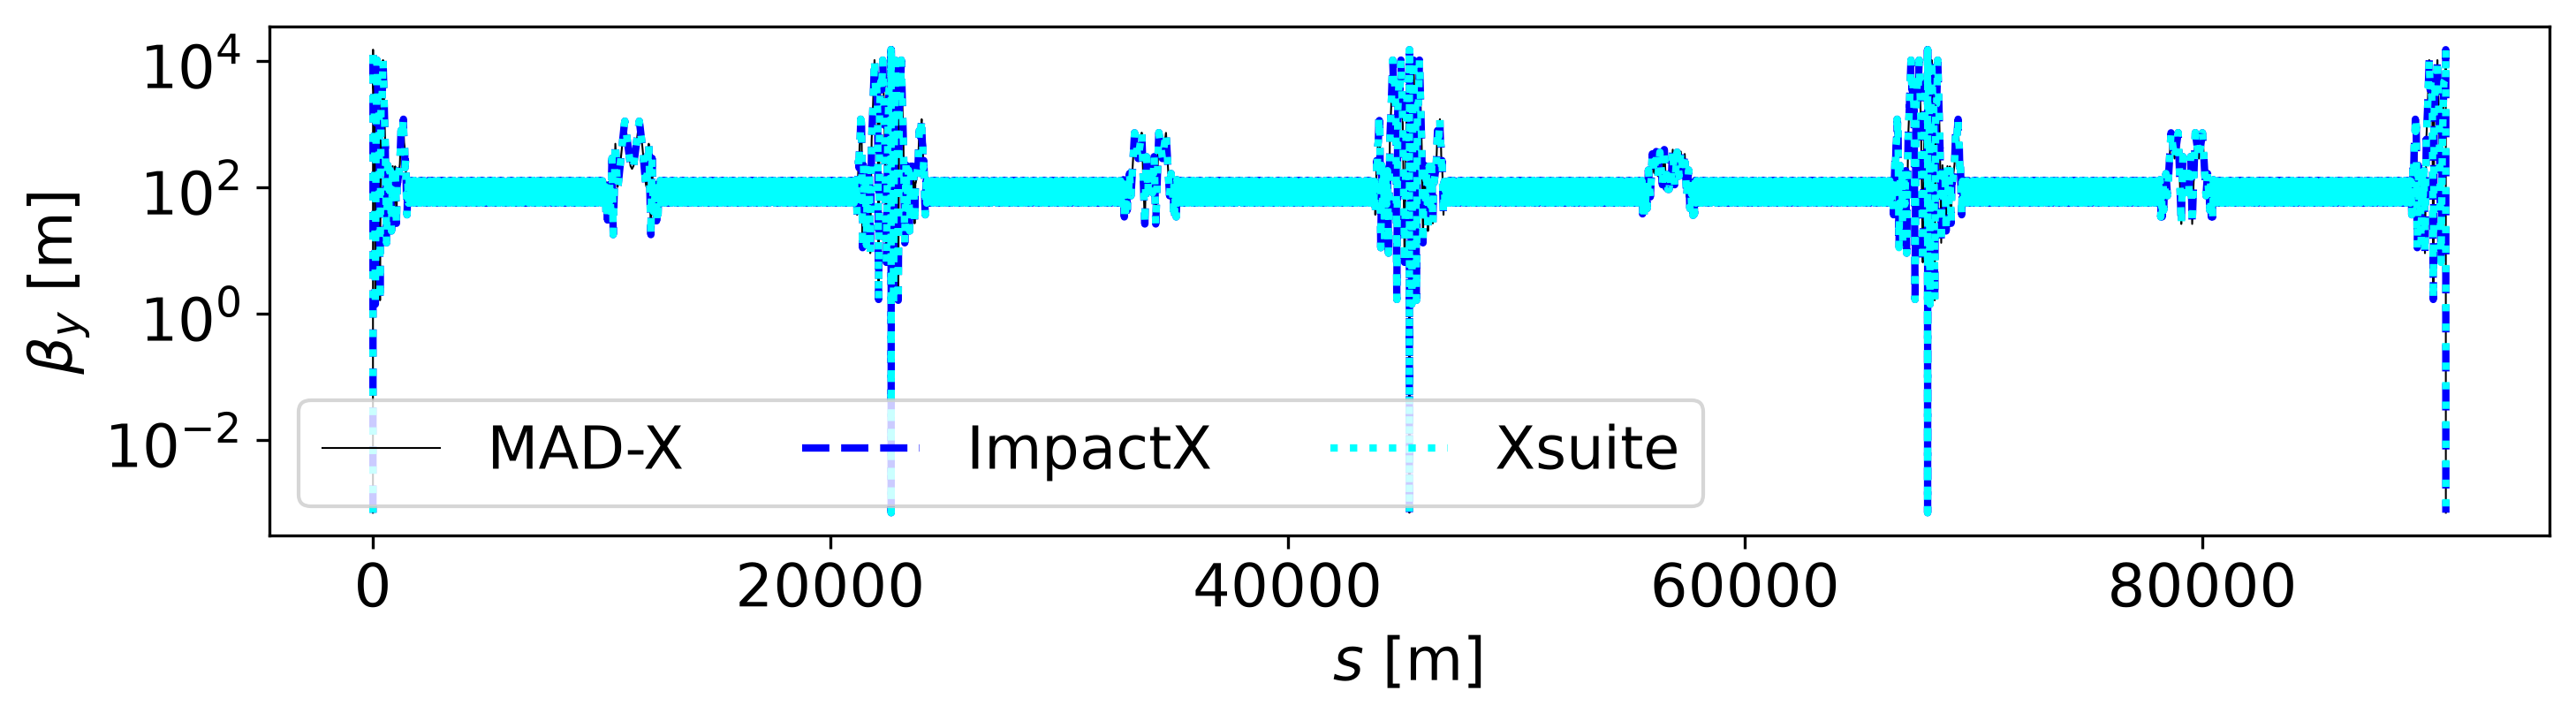

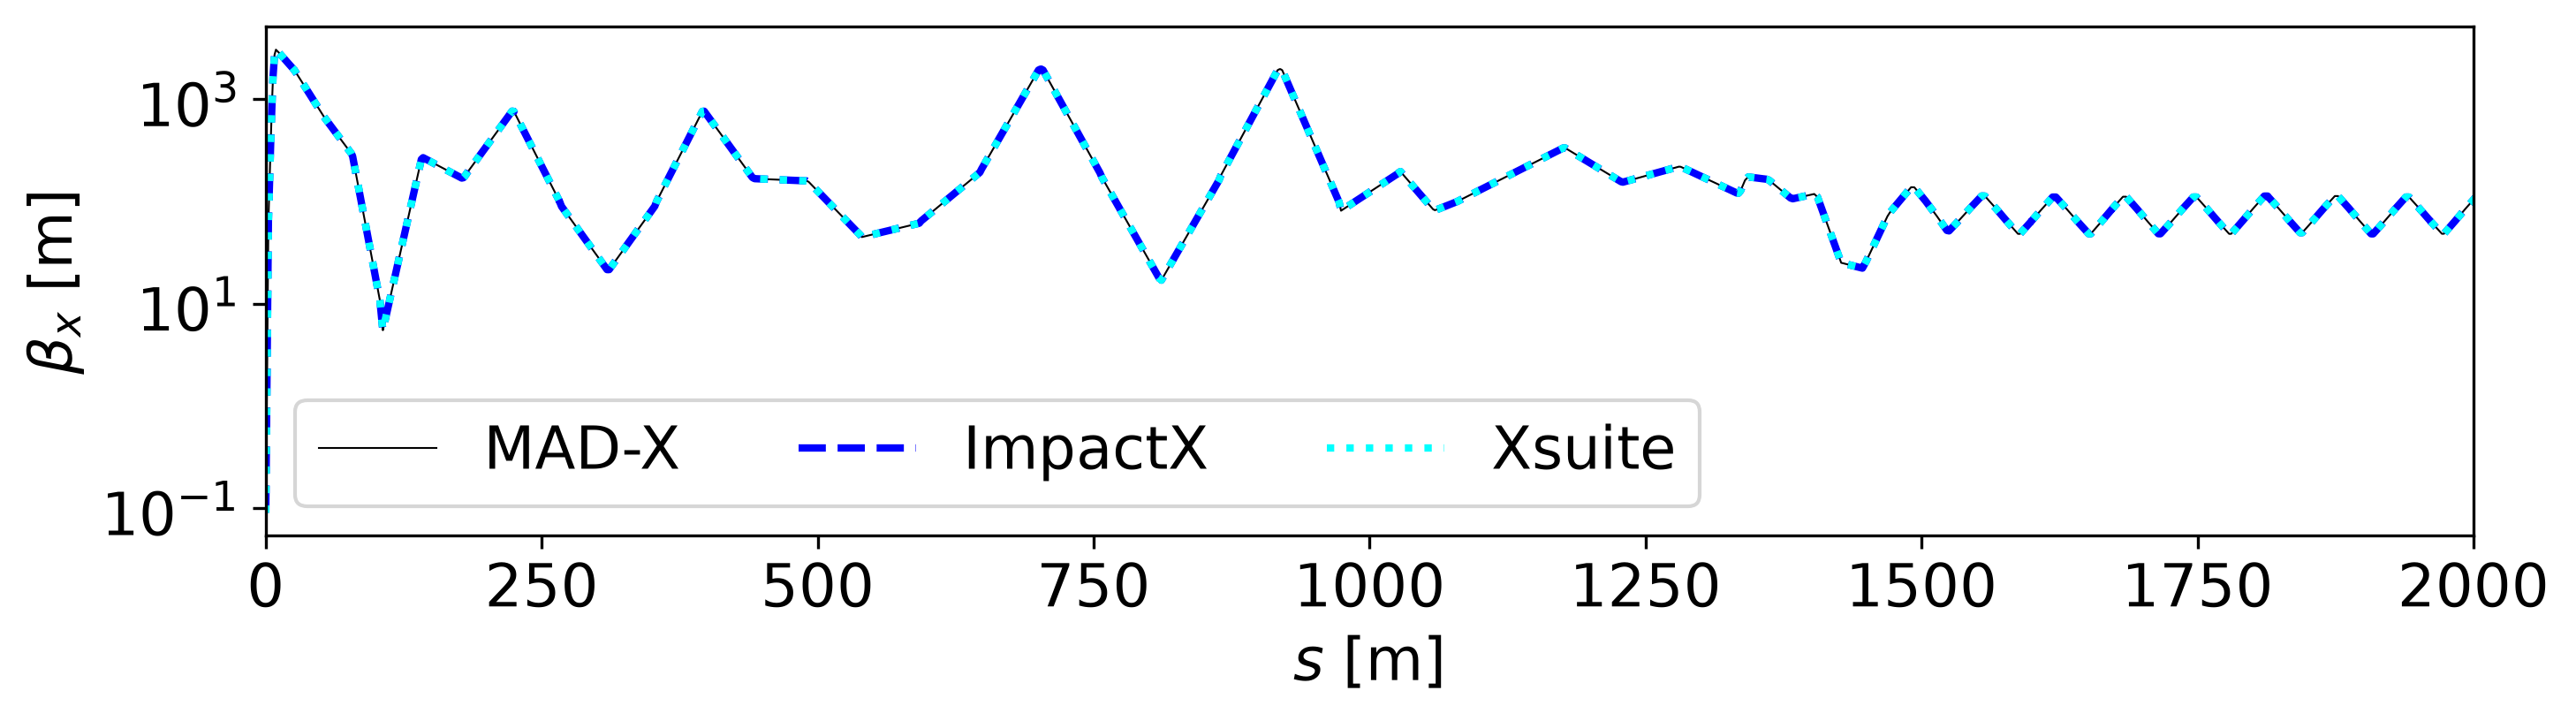

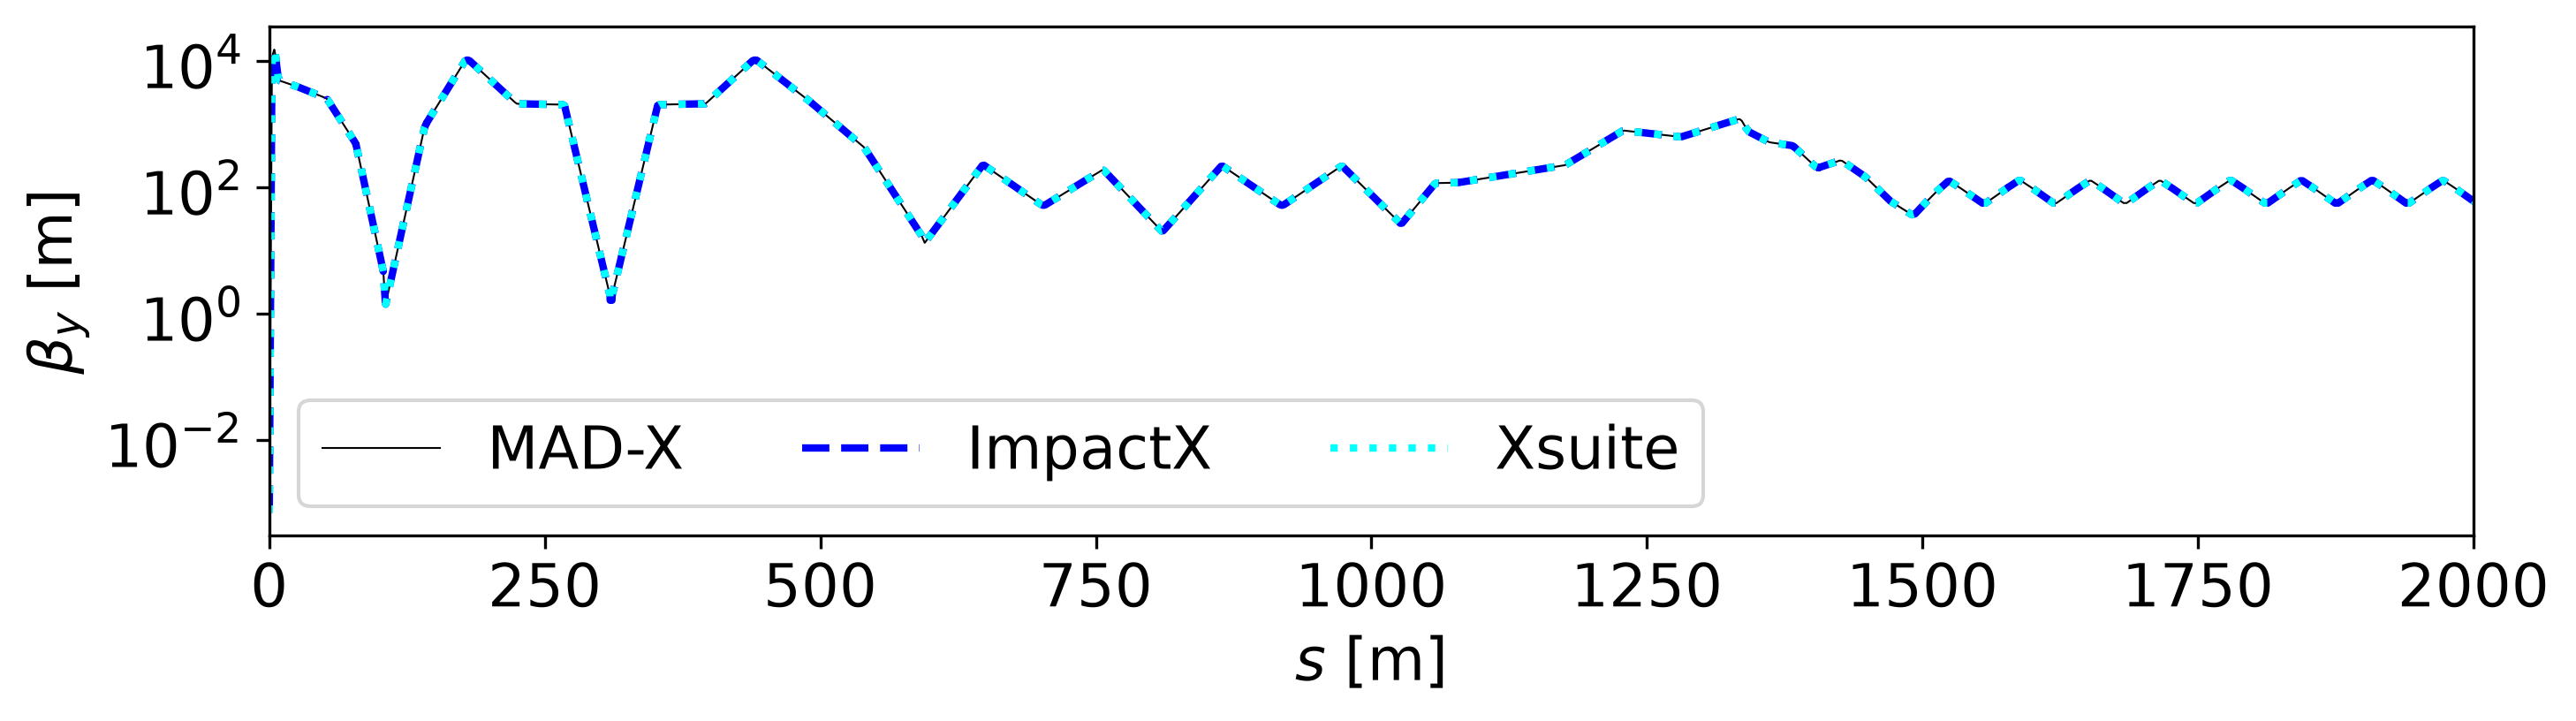

In [5]:
def plot_beta_comparison(quantity, x_limit=None):
    fig, ax = plt.subplots(figsize=(10, 3), dpi=300)
    ax.plot(madx_data['s'], madx_data[quantity],
            color='black', lw=0.5, label='MAD-X')
    ax.plot(impactx['s'], impactx[quantity],
            color='blue', lw=2, ls='--', label='ImpactX')
    ax.plot(xsuite_data['s'], xsuite_data[quantity],
            color='cyan', lw=2, ls=':', label='Xsuite')
    plane = quantity[-1]
    ax.set_xlabel('$s$ [m]')
    ax.set_ylabel(fr'$\beta_{plane}$ [m]')
    ax.set_yscale('log')
    if x_limit is not None:
        ax.set_xlim(0, x_limit)
    ax.legend(ncols=3)
    fig.tight_layout()
    plt.show()

for quantity in ('beta_x', 'beta_y'):
    plot_beta_comparison(quantity)
for quantity in ('beta_x', 'beta_y'):
    plot_beta_comparison(quantity, x_limit=2_000)

## 5. Quantify one-turn closure

Compare the values recorded at $s=0$ at the the beginning of the simulation and after one turn:

$$\Delta\beta_u/\beta_u =(\beta_u(0)-\beta_u(1))/\beta_u(0).$$

In [6]:
for quantity in ('beta_x', 'beta_y'):
    closure = impactx[quantity].iloc[-1] / impactx[quantity].iloc[0] - 1
    print(f'ImpactX {quantity} one-turn closure: {closure:+.3e}')

ImpactX beta_x one-turn closure: +1.890e-04
ImpactX beta_y one-turn closure: +8.549e-04
